## Task: 
Input: <br/>

initial_state = AgentState(number1 = 10, operation="-", number2 = 5, number3 = 7, number4 = 2, operation = "+", finalNumber = 0, finalNumber2 = 0)

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
class AgentState(TypedDict): 
    number1: int
    operation1: str
    number2: int
    number3: int
    operation2: str
    number4: int
    finalNumber1: int
    finalNumber2: int

In [13]:
def adder(state: AgentState) -> AgentState:
    """ This node add 2 numbers """

    state["finalNumber1"] = state["number1"] + state["number2"]
    return state

def subtractor(state: AgentState) -> AgentState:
    """ This node subtracts 2 numbers """

    state["finalNumber1"] = state["number1"] - state["number2"]
    return state

def decider_router(state: AgentState) -> AgentState:
    """ This node selects the next node of the graph """

    if state["operation1"] == "+":
        return "addition_operation"
    
    elif state["operation1"] == "-":
        return "subtraction_operation"
    

def adder2(state: AgentState) -> AgentState:
    """ This node adds 2 number 2nd round """

    state["finalNumber2"] = state["number3"] + state["number4"]
    return state

def subtractor2(state: AgentState) -> AgentState:
    """ This node subtract 2 number 2nd round """

    state["finalNumber2"] = state["number3"] - state["number4"]
    return state

def decider_router2(state: AgentState) -> AgentState:
    """ This node selects the final round node operation route """

    if state["operation2"] == "+":
        return "addition_operation2"
    
    elif state["operation2"] == "-":
        return "subtraction_operation2"

In [14]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtractor_node", subtractor)
graph.add_node("router", lambda state: state)

graph.add_node("add_node2", adder2)
graph.add_node("subtractor_node2", subtractor2)
graph.add_node("router2", lambda state: state)


graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decider_router,
    {
        "addition_operation": "add_node",
        "subtraction_operation": "subtractor_node"
    }
)

graph.add_edge("add_node", "router2")
graph.add_edge("subtractor_node", "router2")

graph.add_conditional_edges(
    "router2",
    decider_router2,
    {
        "addition_operation2": "add_node2",
        "subtraction_operation2": "subtractor_node2"
    }
)

graph.add_edge("add_node2", END)
graph.add_edge("subtractor_node2", END)

app = graph.compile()

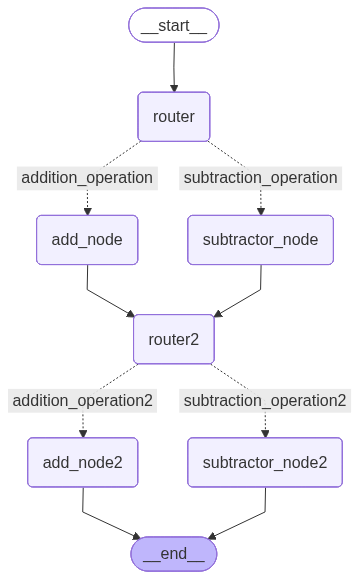

In [15]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [18]:
initial_state = AgentState(number1=10, operation1="-", number2=5, finalNumber1=0, number3=7, operation2="+", number4=2, finalNumber2=0)
print(app.invoke(initial_state))

{'number1': 10, 'operation1': '-', 'number2': 5, 'number3': 7, 'operation2': '+', 'number4': 2, 'finalNumber1': 5, 'finalNumber2': 9}
